# Bays (2014) Figure 4 — GP-Based Equivalent
## Robustness of Error Distributions Under Tuning and Noise Variations

This notebook reproduces Figure 4 from Bays (2014) using Gaussian Process tuning curves
instead of von Mises tuning. The figure tests whether the key finding — that decoding errors
deviate from normality as gain decreases — is robust to changes in tuning properties and noise correlations.

### The six panels test robustness against:
| Panel | Manipulation | GP Equivalent |
|-------|-------------|---------------|
| **a** | Broad tuning (ω = 0.5) | GP lengthscale λ = 1.0 |
| **b** | Narrow tuning (ω = 0.2) | GP lengthscale λ = 0.3 |
| **c** | Baseline activity (f(0) = 0.25) | Constant floor added to GP curves |
| **d** | Heterogeneous tuning | Per-neuron random λ, amplitude, baseline |
| **e** | Cosine tuning | Half-wave rectified cosine (no GP) |
| **f** | Correlated activity (c₀ = 0.25) | Latent Gaussian correlated Poisson |

### Three-row layout:
- **Row 1**: Example tuning curves / correlation matrix
- **Row 2**: Normalised error distributions (colour = gain γ)
- **Row 3**: Deviation from best-fitting circular normal (Δ probability)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy.stats import vonmises, norm, poisson
from scipy.special import i0, i1
import time
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 150

## Core Building Blocks

The model chain is:
1. **Tuning curves** $g_i(\theta)$ — GP-sampled (panels a–d,f) or cosine (panel e)
2. **Divisive normalisation** — $r_i = \gamma \cdot g_i / (\sigma^2 + \bar{g})$
3. **Poisson spikes** — $n_i \sim \text{Poisson}(r_i \cdot T_d)$
4. **ML decoding** — $\hat{\theta} = \arg\max_\theta \sum_i n_i \log g_i(\theta) - T_d \sum_i g_i(\theta)$
5. **Circular error** — $e = \angle(e^{i(\hat{\theta} - \theta_{\text{true}})})$

In [2]:
def periodic_rbf_kernel(thetas, lengthscale):
    """Periodic RBF kernel: K(θ,θ') = exp(-2 sin²(|θ-θ'|/2) / λ²)"""
    diff = thetas[:, None] - thetas[None, :]
    return np.exp(-2.0 * np.sin(diff / 2.0)**2 / lengthscale**2)

def sample_gp_function(K, rng):
    """Draw f ~ GP(0, K). Exponentiate for positive tuning: g = exp(f)."""
    n = K.shape[0]
    L = np.linalg.cholesky(K + 1e-8 * np.eye(n))
    return L @ rng.randn(n)

def dn_pointwise(g_col, gamma, sigma_sq, mean_g):
    """Divisive normalisation: r_i = γ · g_i / (σ² + mean_g)"""
    return gamma * g_col / (sigma_sq + mean_g)

def generate_spikes(rates, T_d, rng):
    """Independent Poisson spikes."""
    return rng.poisson(np.maximum(rates * T_d, 0.0))

def compute_log_likelihood(counts, log_g, T_d_sum_g):
    """LL(θ) = Σ_i n_i · log g_i(θ) - T_d · Σ_i g_i(θ)"""
    return counts @ log_g - T_d_sum_g

def circular_error(theta_true, theta_hat):
    """Signed circular distance in [-π, π]."""
    return np.angle(np.exp(1j * (theta_hat - theta_true)))

## Von Mises Fitting

The crude approximation $\kappa \approx 1/V - 1$ (where $V$ is circular variance) is inaccurate at
high concentrations. We use the Mardia & Jupp (2000) ML approximation based on the mean 
resultant length $\bar{R} = |\langle e^{i \cdot \text{errors}} \rangle|$, which satisfies $I_1(\kappa)/I_0(\kappa) = \bar{R}$.

In [3]:
def estimate_kappa_ml(errors):
    """ML estimate of von Mises κ via Mardia & Jupp (2000) approximation."""
    R_bar = np.abs(np.mean(np.exp(1j * errors)))
    R_bar = np.clip(R_bar, 1e-10, 1.0 - 1e-10)
    if R_bar < 0.53:
        kappa = 2 * R_bar + R_bar**3 + 5 * R_bar**5 / 6
    elif R_bar < 0.85:
        kappa = -0.4 + 1.39 * R_bar + 0.43 / (1 - R_bar)
    else:
        kappa = 1.0 / (2*(1-R_bar) - (1-R_bar)**2 - (1-R_bar)**3)
    return max(kappa, 0.01)

def compute_deviation(errors, n_bins=72):
    """Empirical error histogram minus best-fit von Mises."""
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    emp, _ = np.histogram(errors, bins=bin_edges, density=True)
    kappa = estimate_kappa_ml(errors)
    vm_pdf = vonmises.pdf(centers, kappa)
    return {'centers': centers, 'empirical': emp, 'von_mises': vm_pdf,
            'deviation': emp - vm_pdf, 'kappa': kappa}

## Population Generators

Each panel uses a different population type, testing one specific assumption.

In [4]:
def make_gp_population(M, n_theta, lengthscale, seed):
    """Homogeneous GP population (panels a, b)."""
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    K = periodic_rbf_kernel(thetas, lengthscale)
    g = np.zeros((M, n_theta))
    for i in range(M):
        g[i] = np.exp(sample_gp_function(K, rng))
    return thetas, g

def make_gp_with_baseline(M, n_theta, lengthscale, baseline_frac, seed):
    """GP + constant baseline floor (panel c)."""
    thetas, g = make_gp_population(M, n_theta, lengthscale, seed)
    if baseline_frac > 1e-10:
        mean_peak = np.mean(np.max(g, axis=1))
        f0 = baseline_frac * mean_peak / (1.0 - baseline_frac)
        g = g + f0
    return thetas, g

def make_heterogeneous_population(M, n_theta, config, seed):
    """Heterogeneous: per-neuron random λ, amplitude, baseline (panel d)."""
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    g = np.zeros((M, n_theta))
    lam_mean, lam_std = config.get('lambda_narrow', 0.3), config.get('lambda_std', 0.1)
    for i in range(M):
        lam_i = max(0.05, rng.normal(lam_mean, lam_std))
        amp_i = max(0.01, rng.normal(1.0, 0.5))
        bl_i = max(0.0, rng.normal(0.25, 0.125))
        K = periodic_rbf_kernel(thetas, lam_i)
        g[i] = amp_i * np.exp(sample_gp_function(K, rng)) + bl_i
    return thetas, g

def make_cosine_population(M, n_theta, config, seed):
    """Half-wave rectified cosine tuning (panel e)."""
    rng = np.random.RandomState(seed)
    thetas = np.linspace(-np.pi, np.pi, n_theta, endpoint=False)
    prefs = rng.uniform(-np.pi, np.pi, M)
    g = np.zeros((M, n_theta))
    for i in range(M):
        amp_i = max(0.01, rng.normal(1.0, 0.5))
        bl_i = max(0.0, rng.normal(0.25, 0.125))
        g[i] = amp_i * np.maximum(0.0, np.cos(thetas - prefs[i])) + bl_i
    return thetas, g

## Correlated Spike Generation (Panel f)

Short-range correlations: $c_{ij} = c_0 \exp(-|\theta_i - \theta_j|)$

Generated via the latent Gaussian method (Macke et al. 2008):
sample $z \sim \mathcal{N}(0, C)$, then transform marginals to Poisson via CDF matching.

In [5]:
def build_correlation_matrix(M, c0):
    """Short-range pairwise correlations (Bays Eq. 19)."""
    prefs = np.linspace(-np.pi, np.pi, M, endpoint=False)
    diff = np.abs(prefs[:, None] - prefs[None, :])
    diff = np.minimum(diff, 2*np.pi - diff)
    C = c0 * np.exp(-diff)
    np.fill_diagonal(C, 1.0)
    return C, prefs

def precompute_cholesky(corr_matrix):
    try:
        return np.linalg.cholesky(corr_matrix)
    except np.linalg.LinAlgError:
        eigvals, eigvecs = np.linalg.eigh(corr_matrix)
        eigvals = np.maximum(eigvals, 1e-6)
        C_fixed = eigvecs @ np.diag(eigvals) @ eigvecs.T
        np.fill_diagonal(C_fixed, 1.0)
        return np.linalg.cholesky(C_fixed)

def generate_correlated_spikes(rates, T_d, chol_L, rng):
    """Correlated Poisson via latent Gaussian with precomputed Cholesky."""
    M = len(rates)
    lambdas = np.maximum(rates * T_d, 1e-10)
    z = chol_L @ rng.randn(M)
    u = np.clip(norm.cdf(z), 1e-10, 1.0 - 1e-10)
    counts = poisson.ppf(u, mu=lambdas).astype(int)
    return np.maximum(counts, 0)

## Trial Engine & Panel Runner

In [6]:
def run_trials(g, thetas, gamma, T_d, sigma_sq, n_trials, rng, chol_L=None):
    """Run n_trials of encode → normalise → spike → decode → error."""
    M, n_theta = g.shape
    log_g = np.log(np.maximum(g, 1e-30))
    T_d_sum_g = T_d * np.sum(g, axis=0)
    mean_g = np.mean(g, axis=0)
    errors = np.empty(n_trials)
    for t in range(n_trials):
        idx_true = rng.randint(n_theta)
        rates = dn_pointwise(g[:, idx_true], gamma, sigma_sq, mean_g[idx_true])
        if chol_L is not None:
            counts = generate_correlated_spikes(rates, T_d, chol_L, rng)
        else:
            counts = generate_spikes(rates, T_d, rng)
        ll = compute_log_likelihood(counts, log_g, T_d_sum_g)
        idx_hat = np.argmax(ll)
        errors[t] = circular_error(thetas[idx_true], thetas[idx_hat])
    return errors

## Configuration

In [7]:
N_THETA = 64
N_TRIALS = 3000
N_TRIALS_LARGE = 1500  # for M=1000 (panel f)
T_D = 0.1
SIGMA_SQ = 1e-6
LAMBDA_BROAD = 1.0
LAMBDA_NARROW = 0.3
LAMBDA_STD = 0.1
BASELINE_FRAC = 0.25
C0 = 0.25
GAMMAS = [1, 2, 4, 8, 16, 32, 64, 128]
N_BINS = 72
SEED = 42

config = {
    'n_theta': N_THETA, 'lambda_narrow': LAMBDA_NARROW, 
    'lambda_std': LAMBDA_STD, 'baseline_frac': BASELINE_FRAC, 'c0': C0,
}

## Run All Six Panels

Panels a–e use M=100 only. Panel f uses both M=100 (solid) and M=1000 (dashed).

In [8]:
panel_generators = {
    'a': ('Broad GP\ntuning',    lambda M, s: make_gp_population(M, N_THETA, LAMBDA_BROAD, s)),
    'b': ('Narrow GP\ntuning',   lambda M, s: make_gp_population(M, N_THETA, LAMBDA_NARROW, s)),
    'c': ('Baseline\nactivity',  lambda M, s: make_gp_with_baseline(M, N_THETA, LAMBDA_NARROW, BASELINE_FRAC, s)),
    'd': ('Heterogeneous\ntuning', lambda M, s: make_heterogeneous_population(M, N_THETA, config, s)),
    'e': ('Cosine\ntuning',      lambda M, s: make_cosine_population(M, N_THETA, config, s)),
}

panels = {}
t0 = time.time()

# Panels a–e: M=100 only
for pid, (title, gen_fn) in panel_generators.items():
    pt = time.time()
    thetas, g = gen_fn(100, SEED + ord(pid))
    panels[pid] = {'title': title, 'thetas': thetas, 'g': g, 'pop_sizes': [100], 'results': {}}
    panels[pid]['g_example_100'] = g[:30]
    
    for gam in GAMMAS:
        rng = np.random.RandomState(SEED + 100 + int(gam * 100))
        errs = run_trials(g, thetas, gam, T_D, SIGMA_SQ, N_TRIALS, rng)
        panels[pid]['results'][(gam, 100)] = compute_deviation(errs, N_BINS)
    print(f"  Panel {pid} ({title.split(chr(10))[0]}) done ({time.time()-pt:.1f}s)")

# Panel f: M=100 and M=1000, with correlations
pid = 'f'
pt = time.time()
panels[pid] = {'title': 'Correlated\nactivity', 'pop_sizes': [100, 1000], 'results': {}}

for M in [100, 1000]:
    thetas, g = make_gp_population(M, N_THETA, LAMBDA_NARROW, SEED + M + 500)
    corr_mat, _ = build_correlation_matrix(M, C0)
    chol_L = precompute_cholesky(corr_mat)
    
    panels[pid]['thetas'] = thetas
    panels[pid][f'g_example_{M}'] = g[:30]
    panels[pid][f'corr_matrix_{M}'] = corr_mat
    
    nt = N_TRIALS if M <= 100 else N_TRIALS_LARGE
    for gam in GAMMAS:
        rng = np.random.RandomState(SEED + M + int(gam * 100))
        errs = run_trials(g, thetas, gam, T_D, SIGMA_SQ, nt, rng, chol_L)
        panels[pid]['results'][(gam, M)] = compute_deviation(errs, N_BINS)
    print(f"  Panel f M={M} done")

print(f"\nAll panels done in {time.time()-t0:.1f}s")

  Panel a (Broad GP) done (0.4s)
  Panel b (Narrow GP) done (0.4s)
  Panel c (Baseline) done (0.5s)
  Panel d (Heterogeneous) done (0.4s)
  Panel e (Cosine) done (0.3s)
  Panel f M=100 done
  Panel f M=1000 done

All panels done in 17.2s


## Plot: 3 Rows × 6 Columns

Matching Bays (2014) Figure 4 layout exactly.

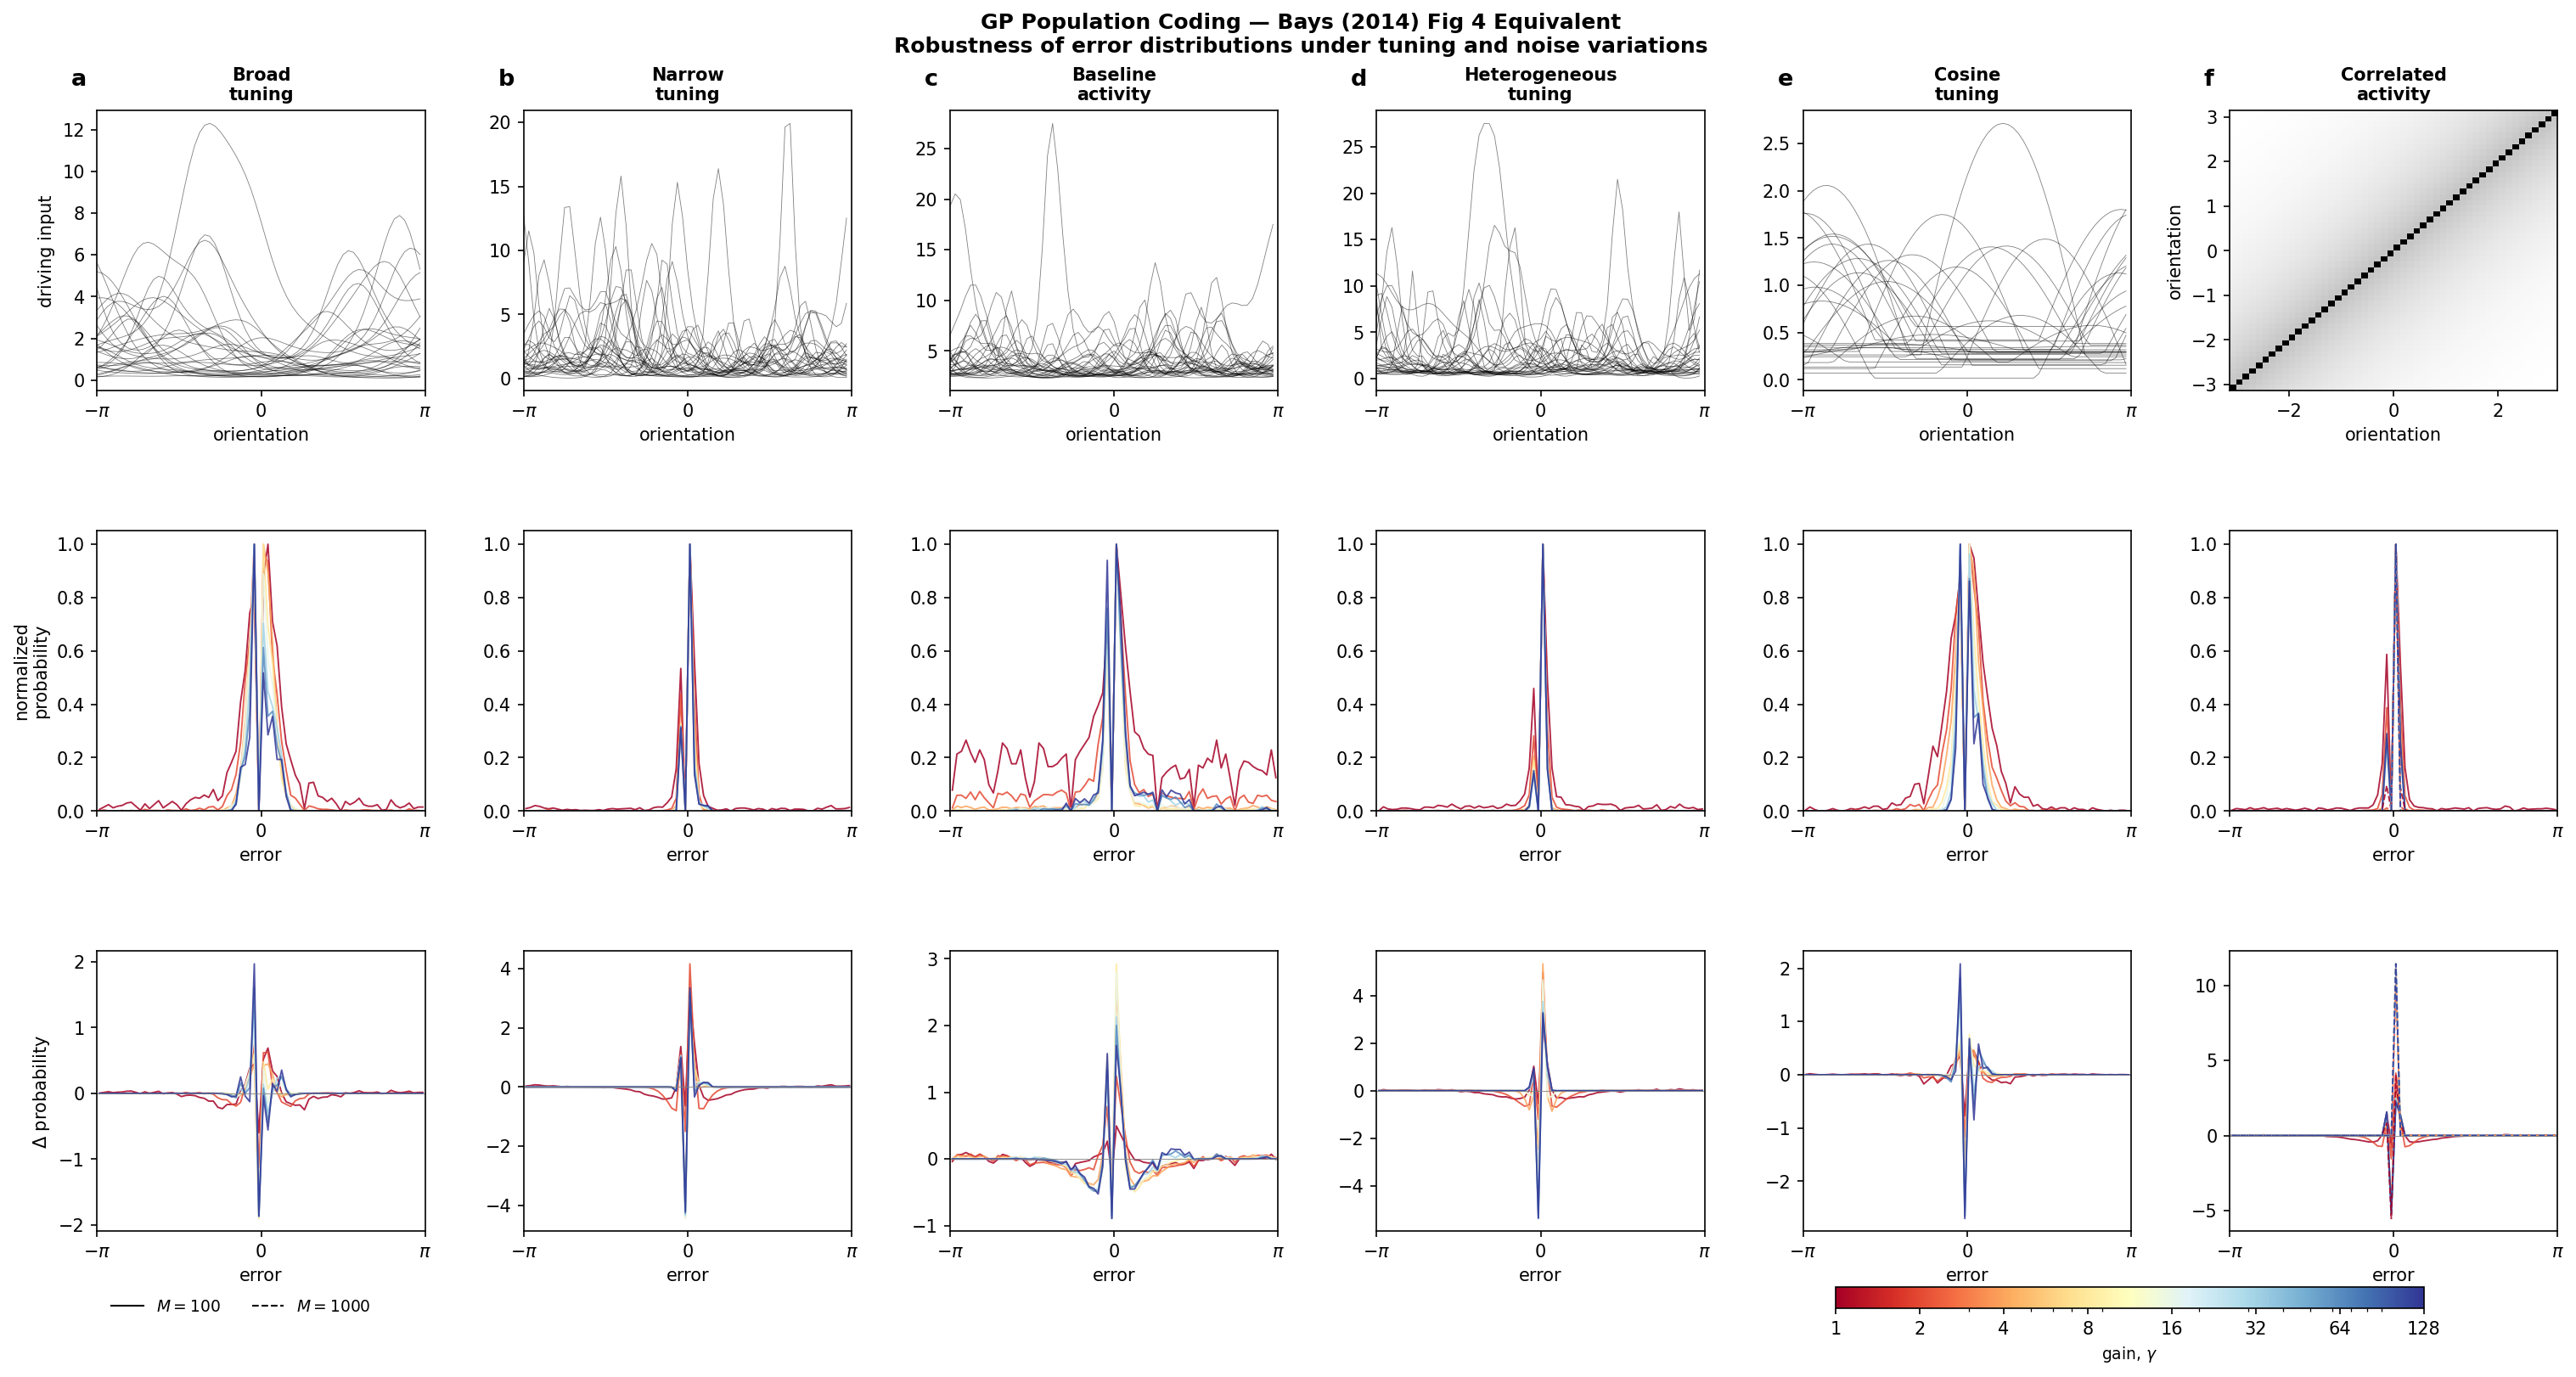

In [9]:
fig = plt.figure(figsize=(21, 11))
gs = gridspec.GridSpec(3, 6, hspace=0.50, wspace=0.30,
                       left=0.05, right=0.97, bottom=0.08, top=0.88)

gain_cmap = plt.cm.RdYlBu
gain_norm = mcolors.LogNorm(vmin=min(GAMMAS), vmax=max(GAMMAS))

panel_ids = ['a', 'b', 'c', 'd', 'e', 'f']
titles = ['Broad\ntuning', 'Narrow\ntuning', 'Baseline\nactivity',
          'Heterogeneous\ntuning', 'Cosine\ntuning', 'Correlated\nactivity']

for col, pid in enumerate(panel_ids):
    p = panels[pid]
    thetas = p['thetas']
    pop_sizes = p['pop_sizes']
    M_ref = pop_sizes[0]
    
    # ── ROW 1: Tuning curves / correlation matrix ──
    ax_top = fig.add_subplot(gs[0, col])
    if pid == 'f':
        C = p[f'corr_matrix_{M_ref}']
        n_show = min(50, C.shape[0])
        ax_top.imshow(C[:n_show, :n_show], cmap='gray_r', origin='lower',
                      aspect='auto', extent=[-np.pi, np.pi, -np.pi, np.pi])
        ax_top.set_xlabel('orientation'); ax_top.set_ylabel('orientation')
    else:
        g_ex = p.get(f'g_example_{M_ref}', p['g'][:30])
        for i in range(min(30, g_ex.shape[0])):
            ax_top.plot(thetas, g_ex[i], 'k-', lw=0.4, alpha=0.5)
        ax_top.set_xlabel('orientation')
        if col == 0: ax_top.set_ylabel('driving input')
        ax_top.set_xlim(-np.pi, np.pi)
        ax_top.set_xticks([-np.pi, 0, np.pi])
        ax_top.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    
    ax_top.set_title(titles[col], fontsize=10, fontweight='bold')
    ax_top.text(-0.08, 1.15, f'$\\mathbf{{{pid}}}$',
                transform=ax_top.transAxes, fontsize=13, fontweight='bold', va='top')
    
    # ── ROW 2: Normalised error distributions ──
    ax_mid = fig.add_subplot(gs[1, col])
    for M in pop_sizes:
        ls = '-' if M == pop_sizes[0] else '--'
        for gam in GAMMAS:
            key = (gam, M)
            if key not in p['results']: continue
            dev = p['results'][key]
            emp = dev['empirical']
            peak = emp.max()
            ax_mid.plot(dev['centers'], emp/peak if peak > 0 else emp,
                        color=gain_cmap(gain_norm(gam)), lw=0.9, ls=ls, alpha=0.85)
    ax_mid.set_xlim(-np.pi, np.pi); ax_mid.set_ylim(0, 1.05)
    ax_mid.set_xticks([-np.pi, 0, np.pi])
    ax_mid.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax_mid.set_xlabel('error')
    if col == 0: ax_mid.set_ylabel('normalized\nprobability')
    
    # ── ROW 3: Deviation from circular normal ──
    ax_bot = fig.add_subplot(gs[2, col])
    for M in pop_sizes:
        ls = '-' if M == pop_sizes[0] else '--'
        for gam in GAMMAS:
            key = (gam, M)
            if key not in p['results']: continue
            dev = p['results'][key]
            ax_bot.plot(dev['centers'], dev['deviation'],
                        color=gain_cmap(gain_norm(gam)), lw=0.9, ls=ls, alpha=0.85)
    ax_bot.axhline(0, color='gray', lw=0.4)
    ax_bot.set_xlim(-np.pi, np.pi)
    ax_bot.set_xticks([-np.pi, 0, np.pi])
    ax_bot.set_xticklabels([r'$-\pi$', '0', r'$\pi$'])
    ax_bot.set_xlabel('error')
    if col == 0: ax_bot.set_ylabel(r'$\Delta$ probability')

# Legend & colorbar
from matplotlib.lines import Line2D
handles = [Line2D([0],[0], color='k', lw=1, ls='-', label='$M=100$'),
           Line2D([0],[0], color='k', lw=1, ls='--', label='$M=1000$')]
fig.legend(handles=handles, loc='lower left', bbox_to_anchor=(0.05, 0.01),
           fontsize=9, frameon=False, ncol=2)

sm = plt.cm.ScalarMappable(cmap=gain_cmap, norm=gain_norm); sm.set_array([])
cbar_ax = fig.add_axes([0.70, 0.025, 0.22, 0.015])
cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cb.set_label(r'gain, $\gamma$', fontsize=9)
cb.set_ticks(GAMMAS); cb.set_ticklabels([str(int(g)) for g in GAMMAS])

fig.suptitle('GP Population Coding — Bays (2014) Fig 4 Equivalent\n'
             'Robustness of error distributions under tuning and noise variations',
             fontsize=12, fontweight='bold', y=0.95)
plt.show()

## Key Observations

**Across all six panels, the same qualitative pattern holds:**

1. **High gain (blue curves)**: Errors are tightly peaked and well-approximated by a von Mises distribution. The Δ probability row shows near-zero deviations.

2. **Low gain (red curves)**: Errors become broader AND deviate from normality — the Δ probability shows positive deviation at the centre (sharper peak) and in the tails (heavier tails), with negative deviation in between.

3. **The deviation pattern is robust**: Whether tuning is broad or narrow, has baseline or not, is heterogeneous or cosine-shaped, the same "peaked centre + heavy tails" signature appears at low gains.

4. **Panel f is the exception that proves the rule**: Short-range correlations decrease precision (compare solid vs dashed lines for the same gain colour), and this effect depends on population size. But the *shape* of deviations is unchanged.

### Why this matters for the GP framework:
The GP tuning curves produce the same robustness pattern as Bays's von Mises tuning. This validates the GP approach as a legitimate generalisation — the phenomenon arises from the **Poisson noise + ML decoding** structure, not from the specific functional form of the tuning curves.